# 3 — Análise exploratória do taxi-out (CGH 2025)

Lê `data/processed/cgh_taxi_features_2025.parquet` (gerado pelo notebook `2`) e
explora a variável dependente `taxi_out_min` e sua relação com **mês**, **dia da
semana**, **bloco de horário**, **companhia** e **meteorologia** (chuva, vento,
teto, visibilidade). Estilo inspirado no script de modelagem multinível do curso.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processed/cgh_taxi_features_2025.parquet")
DIAS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DIAS_PT = ["Segunda", "Terca", "Quarta", "Quinta", "Sexta", "Sabado", "Domingo"]
df["dia_semana"] = pd.Categorical(df["dia_semana"], categories=DIAS_PT, ordered=True)
print(len(df), "decolagens")
df["taxi_out_min"].describe().round(2)

75013 decolagens


count    75013.00
mean        14.93
std          5.17
min          3.02
25%         11.22
50%         13.92
75%         17.58
max         76.30
Name: taxi_out_min, dtype: float64

## 3.1 Distribuição da variável dependente

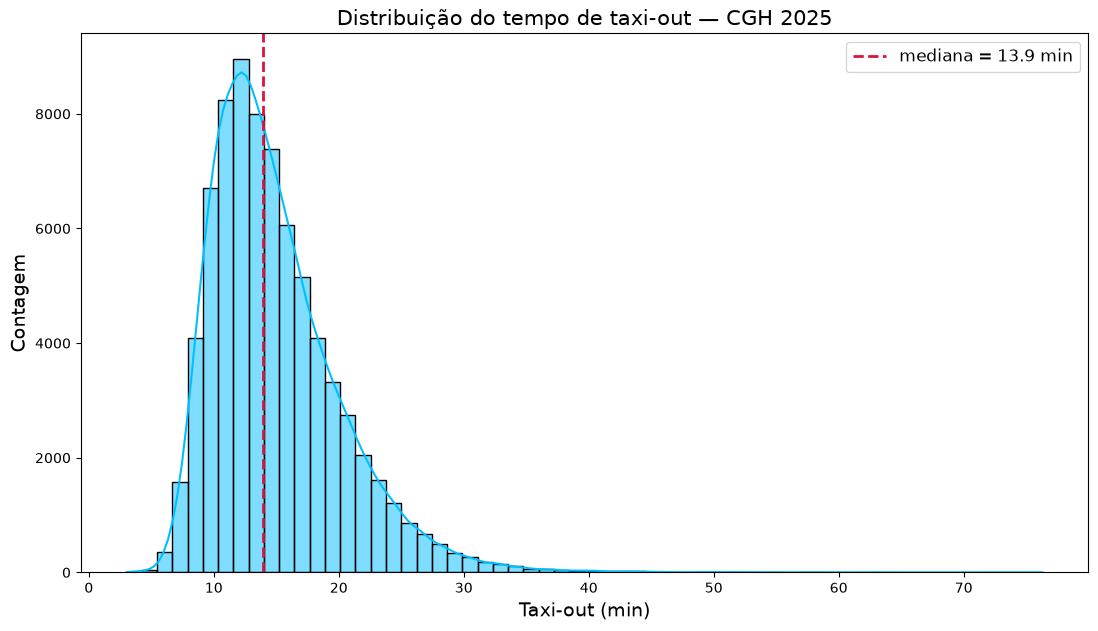

In [2]:
plt.figure(figsize=(13, 7))
sns.histplot(df["taxi_out_min"], kde=True, bins=60, color="deepskyblue")
plt.axvline(df["taxi_out_min"].median(), color="crimson", ls="--", lw=2,
            label=f"mediana = {df['taxi_out_min'].median():.1f} min")
plt.xlabel("Taxi-out (min)", fontsize=14)
plt.ylabel("Contagem", fontsize=14)
plt.title("Distribuição do tempo de taxi-out — CGH 2025", fontsize=15)
plt.legend(fontsize=12)
plt.show()

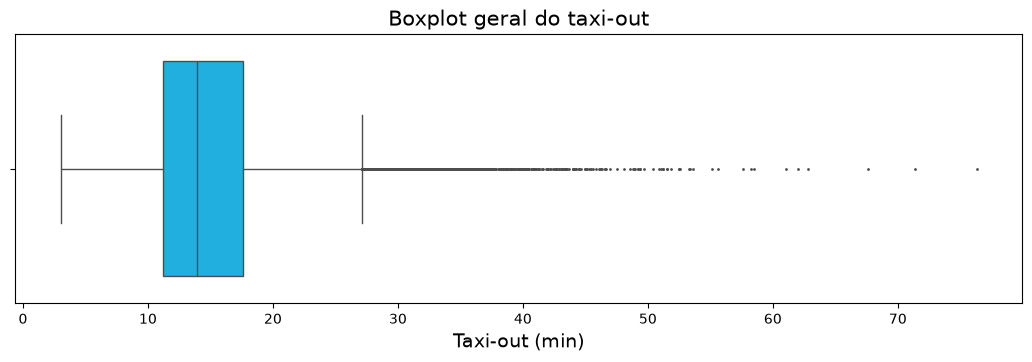

In [3]:
plt.figure(figsize=(13, 3.5))
sns.boxplot(x=df["taxi_out_min"], color="deepskyblue", fliersize=1)
plt.xlabel("Taxi-out (min)", fontsize=14)
plt.title("Boxplot geral do taxi-out", fontsize=15)
plt.show()

In [12]:
df['taxi_out_min'].describe()

count    75013.000000
mean        14.929333
std          5.172968
min          3.016667
25%         11.216667
50%         13.916667
75%         17.583333
max         76.300000
Name: taxi_out_min, dtype: float64

## 3.2 Taxi-out por mês

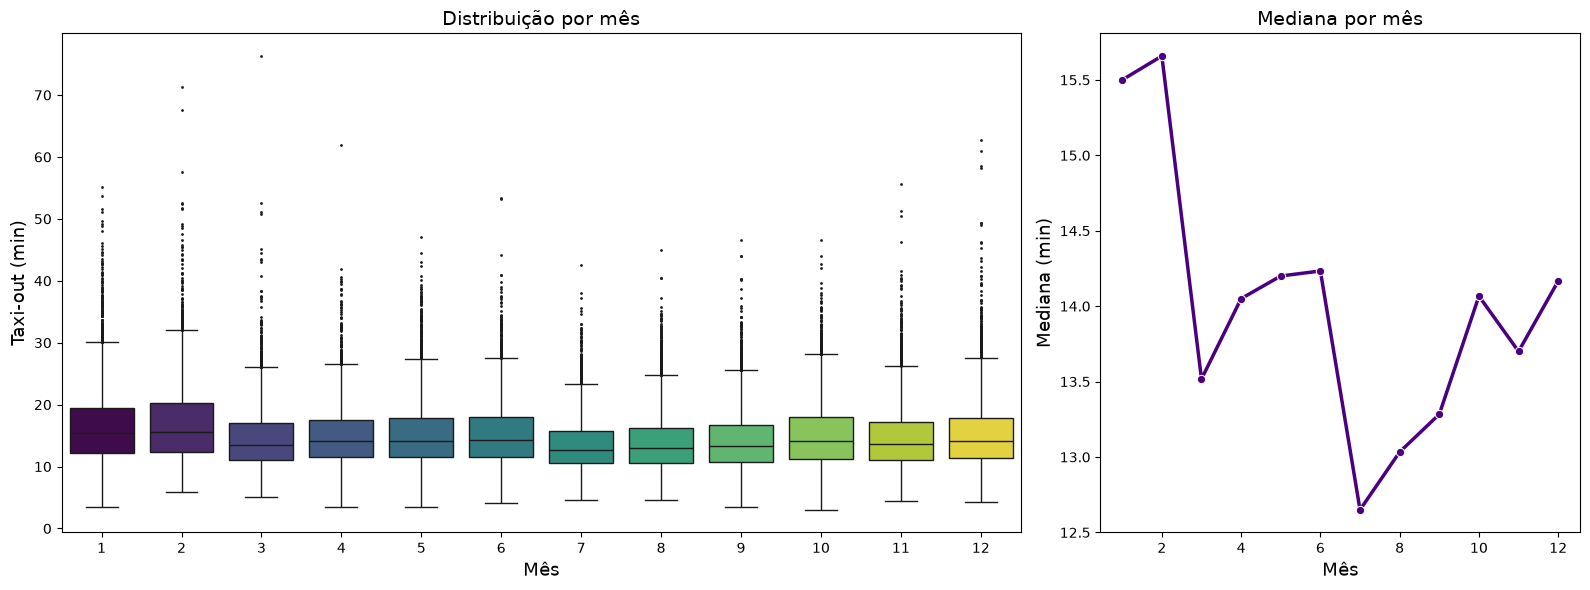

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})
sns.boxplot(data=df, x="mes", y="taxi_out_min", ax=ax[0], palette="viridis",
            fliersize=1, hue="mes", legend=False)
ax[0].set_xlabel("Mês", fontsize=13); ax[0].set_ylabel("Taxi-out (min)", fontsize=13)
ax[0].set_title("Distribuição por mês", fontsize=14)

med = df.groupby("mes", observed=True)["taxi_out_min"].median()
sns.lineplot(x=med.index, y=med.values, marker="o", color="indigo", lw=2.5, ax=ax[1])
ax[1].set_xlabel("Mês", fontsize=13); ax[1].set_ylabel("Mediana (min)", fontsize=13)
ax[1].set_title("Mediana por mês", fontsize=14)
plt.tight_layout()
plt.show()

## 3.3 Taxi-out por dia da semana

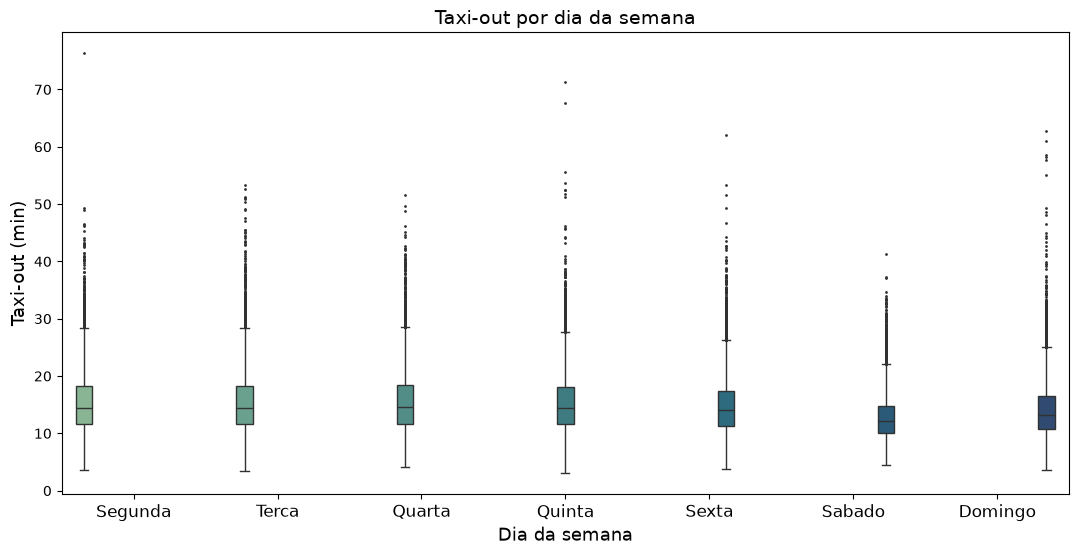

,count,median,mean
dia_semana,,,
Segunda,11463,14.40,15.40
Terca,11516,14.42,15.46
Quarta,11627,14.58,15.55
Quinta,11468,14.37,15.33
Sexta,11182,14.00,14.86
Sabado,7699,12.08,12.90
Domingo,10058,13.22,14.24


In [5]:
plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x="dia_semana", y="taxi_out_min", order=DIAS_PT,
            palette="crest", fliersize=1, hue="dia_semana", legend=False)
plt.xticks(range(7), DIAS_PT, fontsize=12)
plt.xlabel("Dia da semana", fontsize=13); plt.ylabel("Taxi-out (min)", fontsize=13)
plt.title("Taxi-out por dia da semana", fontsize=14)
plt.show()

df.groupby("dia_semana", observed=True)["taxi_out_min"].agg(["count", "median", "mean"]).round(2)

## 3.4 Taxi-out por bloco de horário (perfil intradiário)

É aqui que se espera o maior efeito: os picos de congestionamento na pista alongam o taxi.

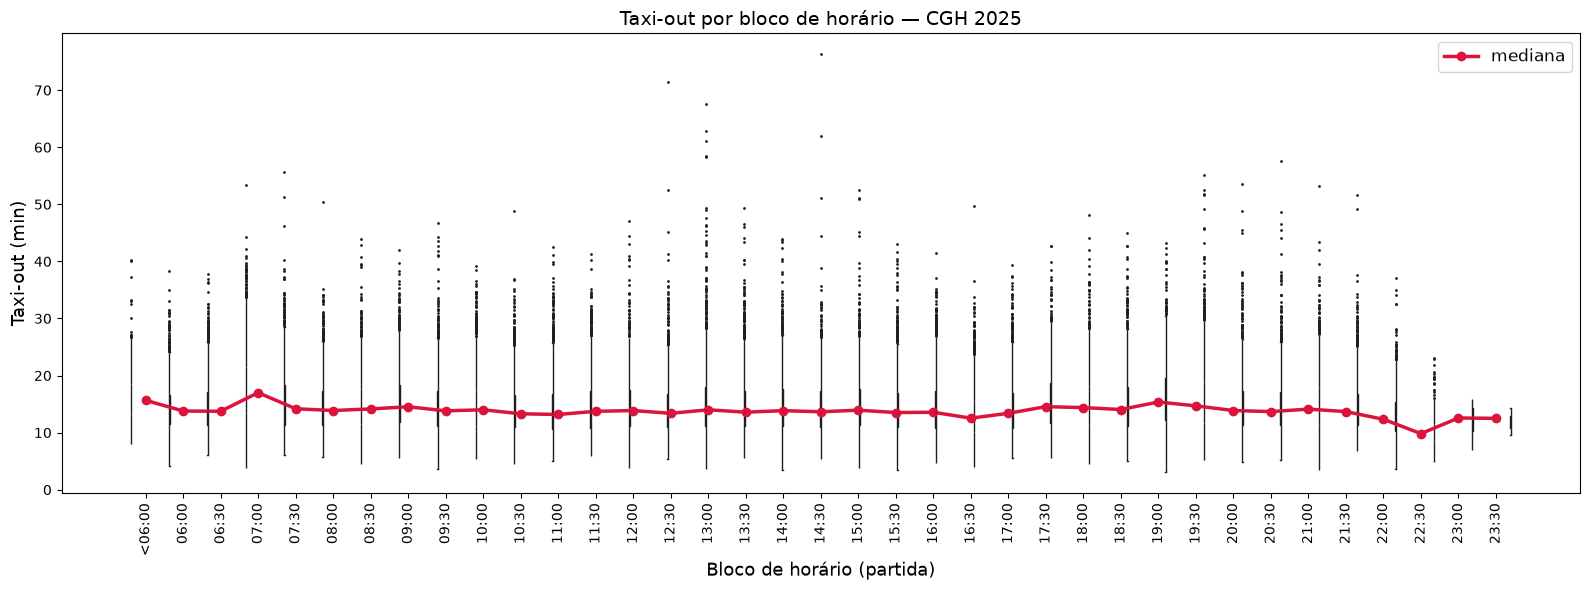

In [6]:
ordem = list(df["bloco"].cat.categories)
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x="bloco", y="taxi_out_min", order=ordem,
            palette="viridis", fliersize=1, hue="bloco", legend=False)
med = df.groupby("bloco", observed=True)["taxi_out_min"].median().reindex(ordem)
plt.plot(range(len(ordem)), med.values, color="crimson", lw=2.5, marker="o",
         label="mediana")
plt.xticks(rotation=90, fontsize=10)
plt.xlabel("Bloco de horário (partida)", fontsize=13)
plt.ylabel("Taxi-out (min)", fontsize=13)
plt.title("Taxi-out por bloco de horário — CGH 2025", fontsize=14)
plt.legend(fontsize=12); plt.tight_layout(); plt.show()

## 3.5 Mapa de calor: bloco de horário × dia da semana (mediana do taxi-out)

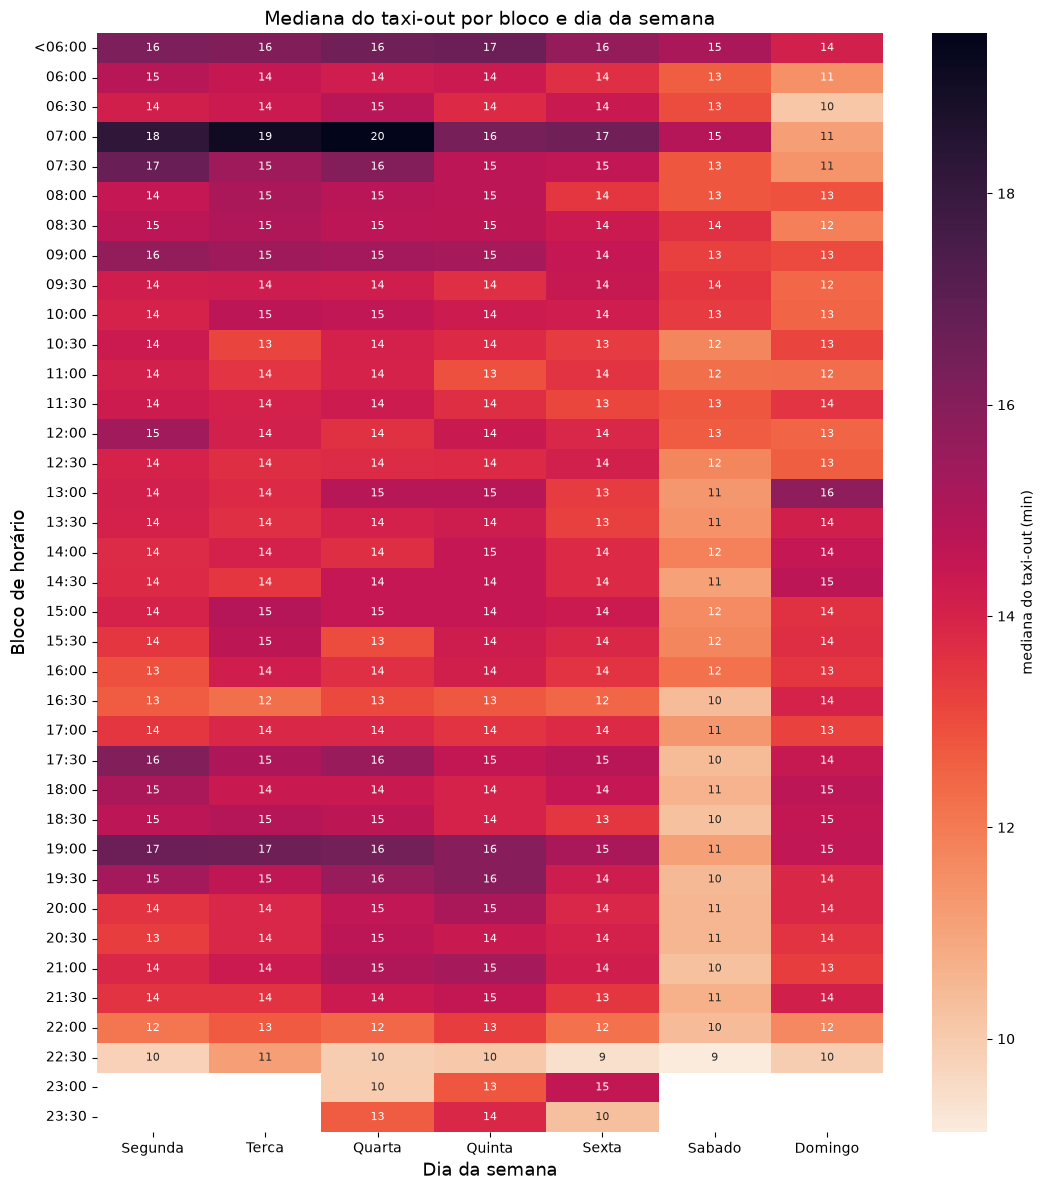

In [7]:
ordem = list(df["bloco"].cat.categories)
piv = df.pivot_table(index="bloco", columns="dia_semana", values="taxi_out_min",
                     aggfunc="median", observed=True).reindex(ordem)
plt.figure(figsize=(11, 12))
sns.heatmap(piv, cmap="rocket_r", annot=True, fmt=".0f", annot_kws={"size": 8},
            cbar_kws={"label": "mediana do taxi-out (min)"})
plt.xticks(np.arange(7) + 0.5, DIAS_PT, rotation=0)
plt.xlabel("Dia da semana", fontsize=13); plt.ylabel("Bloco de horário", fontsize=13)
plt.title("Mediana do taxi-out por bloco e dia da semana", fontsize=14)
plt.tight_layout(); plt.show()

## 3.6 Taxi out por cia_aerea

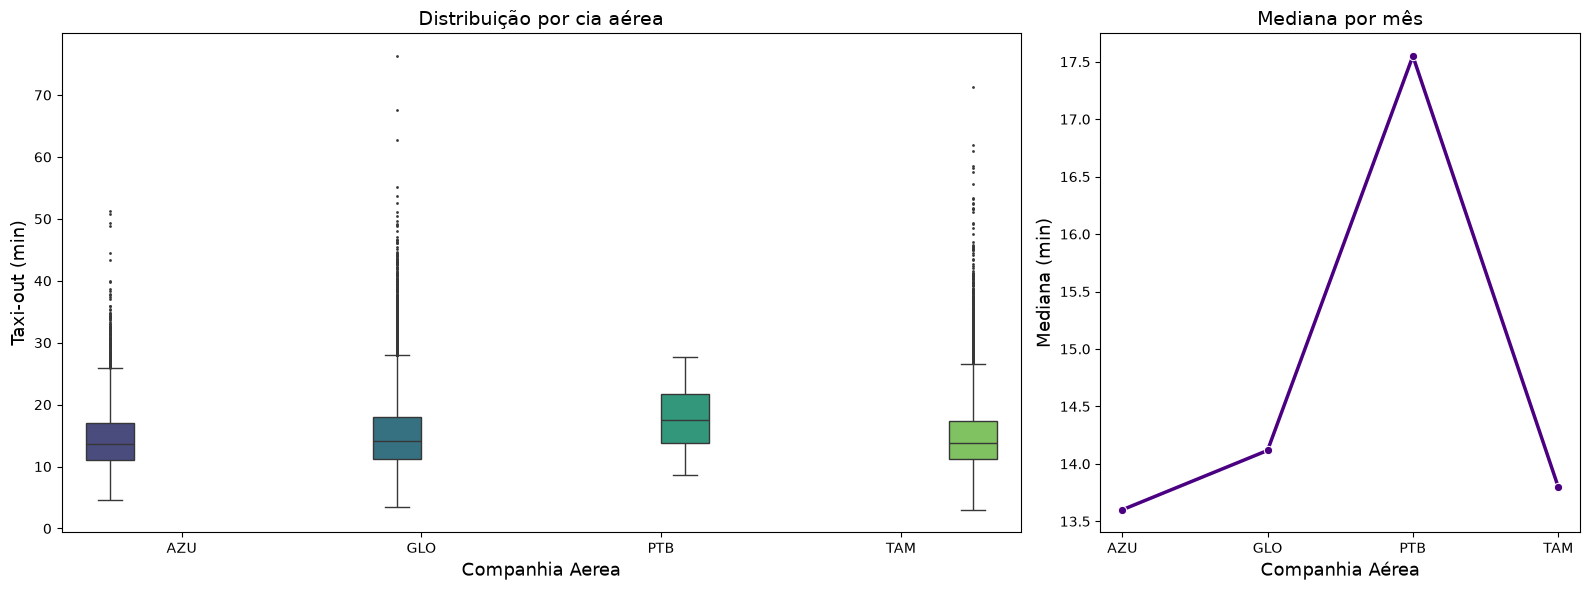

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})
sns.boxplot(data=df, x="cia_aerea", y="taxi_out_min", ax=ax[0], palette="viridis",
            fliersize=1, hue="cia_aerea", legend=False)
ax[0].set_xlabel("Companhia Aerea", fontsize=13); ax[0].set_ylabel("Taxi-out (min)", fontsize=13)
ax[0].set_title("Distribuição por cia aérea", fontsize=14)

med = df.groupby("cia_aerea", observed=True)["taxi_out_min"].median()
sns.lineplot(x=med.index, y=med.values, marker="o", color="indigo", lw=2.5, ax=ax[1])
ax[1].set_xlabel("Companhia Aérea", fontsize=13); ax[1].set_ylabel("Mediana (min)", fontsize=13)
ax[1].set_title("Mediana por mês", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
df.groupby("cia_aerea", observed=True)["taxi_out_min"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
cia_aerea,,,,,,,,
AZU,8682.0,14.55,4.81,4.57,11.10,13.60,17.05,51.22
GLO,31674.0,15.13,5.40,3.55,11.28,14.12,17.96,76.30
PTB,57.0,17.87,4.99,8.58,13.78,17.55,21.67,27.68
TAM,34600.0,14.84,5.04,3.02,11.22,13.80,17.38,71.37


## 3.7 Taxi-out e meteorologia

As quatro variáveis de tempo significativo, cada uma como categórica ordinal com
o **bom tempo** como referência. O padrão esperado: o taxi cresce à medida que a
condição piora, mas as faixas severas são raras — o `n` de cada faixa aparece no
eixo, para não superinterpretar coeficientes de poucos voos.

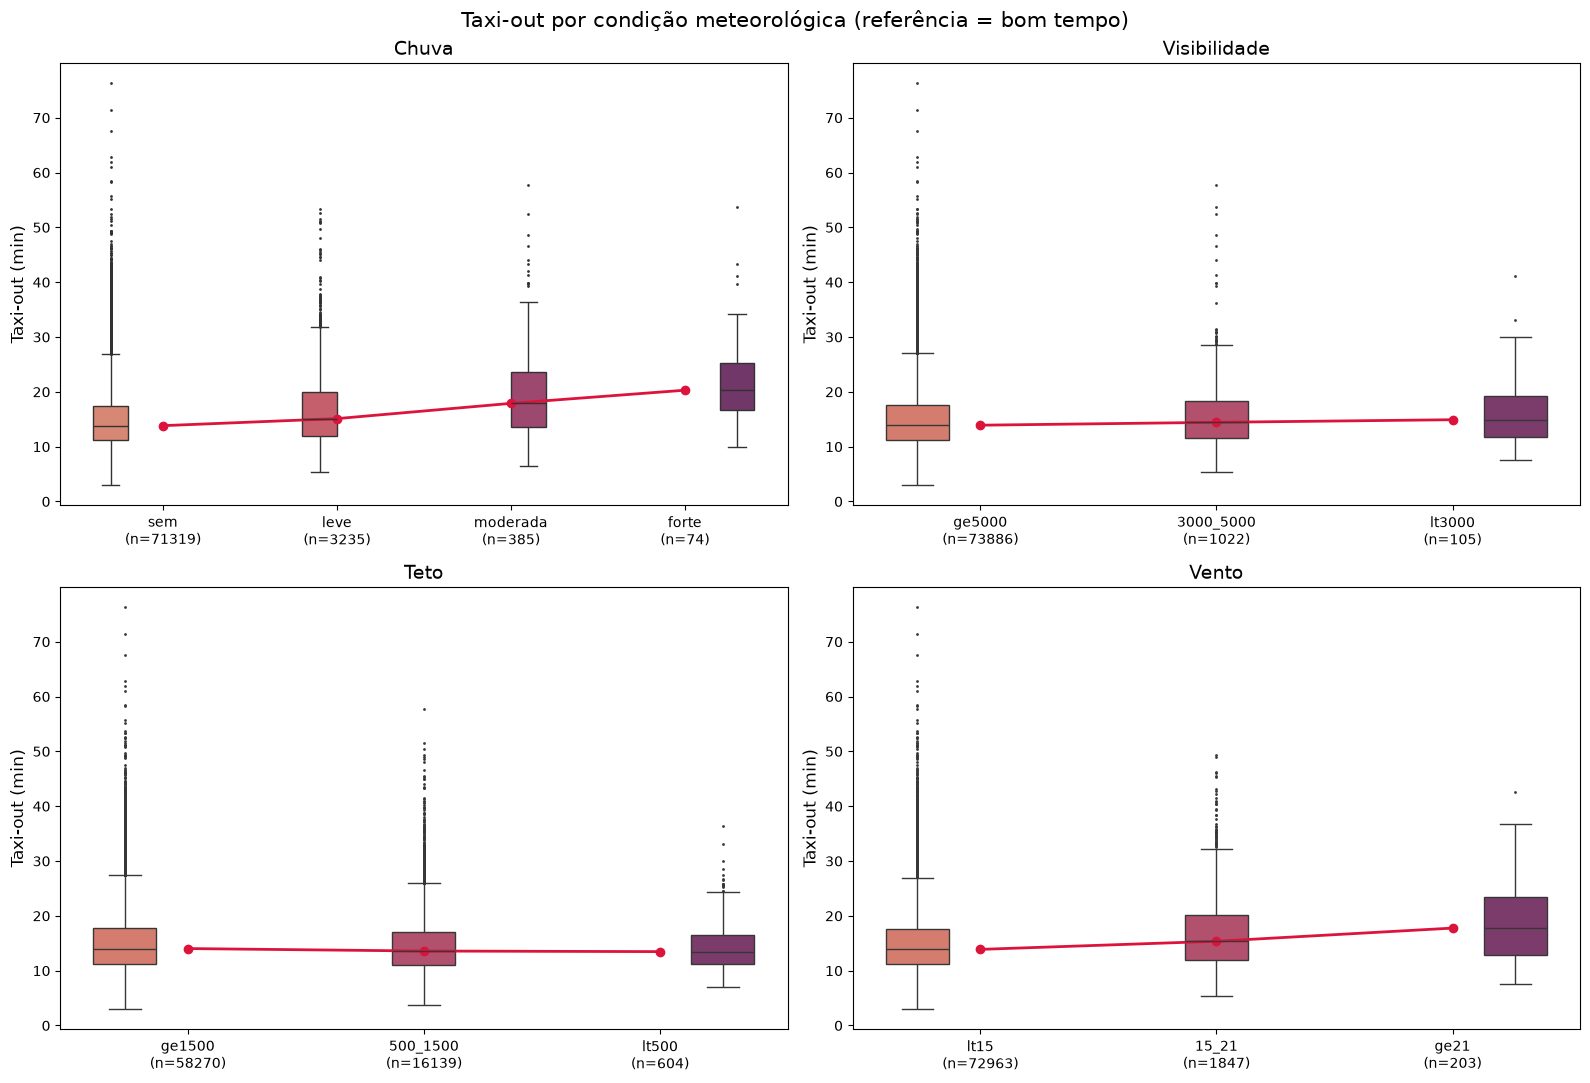

chuva      {'sem': 13.8, 'leve': 15.1, 'moderada': 17.9, 'forte': 20.3}
vis_cat    {'ge5000': 13.9, '3000_5000': 14.4, 'lt3000': 14.9}
teto_cat   {'ge1500': 14.0, '500_1500': 13.6, 'lt500': 13.5}
vento_cat  {'lt15': 13.9, '15_21': 15.4, 'ge21': 17.8}


In [9]:
METEO = {"chuva": "Chuva", "vis_cat": "Visibilidade",
         "teto_cat": "Teto", "vento_cat": "Vento"}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, (col, titulo) in zip(axes.ravel(), METEO.items()):
    ordem = list(df[col].cat.categories)
    # rotulos com o n de cada faixa
    n = df[col].value_counts()
    rot = [f"{c}\n(n={int(n.get(c, 0))})" for c in ordem]
    sns.boxplot(data=df, x=col, y="taxi_out_min", order=ordem, ax=ax,
                palette="flare", fliersize=1, hue=col, legend=False)
    med = df.groupby(col, observed=True)["taxi_out_min"].median().reindex(ordem)
    ax.plot(range(len(ordem)), med.values, color="crimson", lw=2, marker="o")
    ax.set_xticks(range(len(ordem))); ax.set_xticklabels(rot, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("Taxi-out (min)", fontsize=12)
    ax.set_title(titulo, fontsize=14)
plt.suptitle("Taxi-out por condição meteorológica (referência = bom tempo)", fontsize=15)
plt.tight_layout(); plt.show()

# mediana por faixa, para leitura numerica
for col in METEO:
    med = df.groupby(col, observed=True)["taxi_out_min"].median().round(1)
    print(f"{col:10}", med.to_dict())

## 3.8 Taxi-out: feriado vs dia normal
`feriado` = 1 nos feriados, vésperas e pós-feriados (feriados em sáb/dom não contam).

,n,media,mediana,dp,p25,p75
feriado_lbl,,,,,,
Dia normal,69920,14.98,14.00,5.19,11.25,17.67
Feriado (+ vesp/pos),5093,14.19,13.22,4.85,10.87,16.42


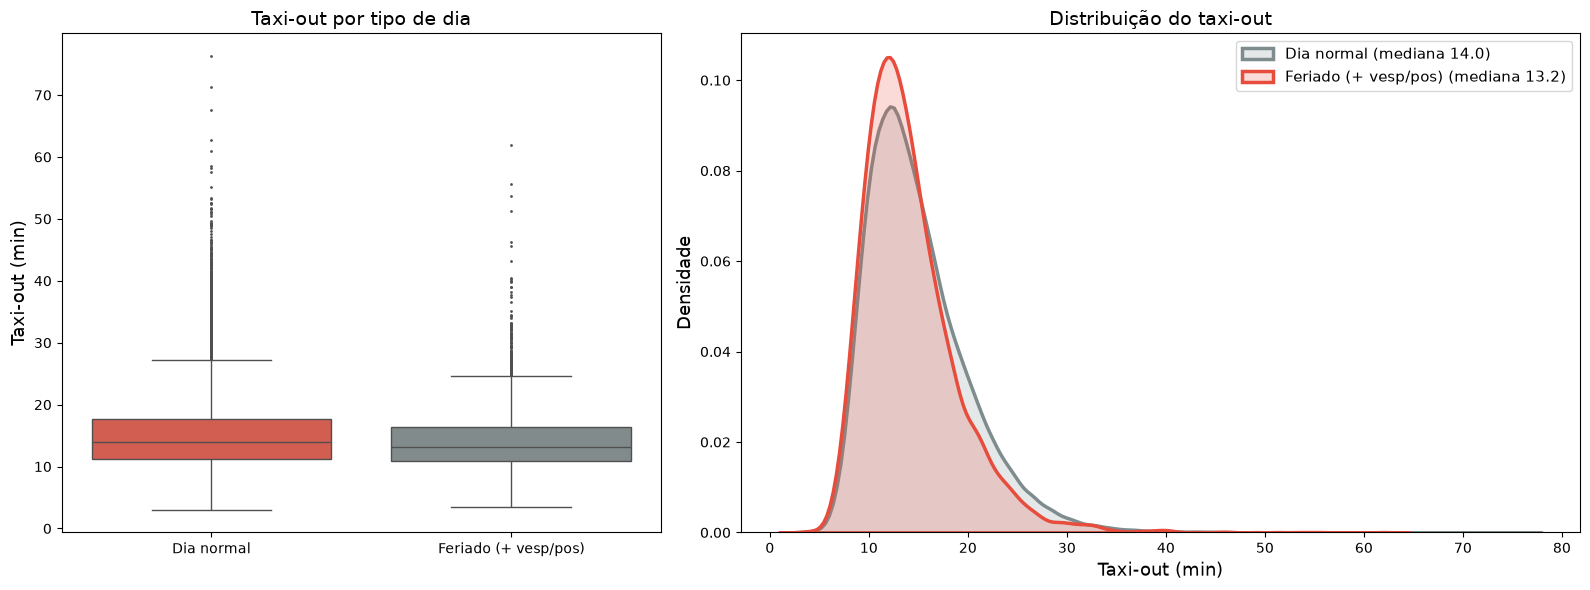

In [10]:
df["feriado_lbl"] = df["feriado"].map({0: "Dia normal", 1: "Feriado (+ vesp/pos)"})
ordem = ["Dia normal", "Feriado (+ vesp/pos)"]

# resumo estatistico por grupo
resumo = (df.groupby("feriado_lbl", observed=True)["taxi_out_min"]
          .agg(n="count", media="mean", mediana="median", dp="std",
               p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
          .reindex(ordem).round(2))
display(resumo)

# graficos: boxplot + distribuicao
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})
sns.boxplot(data=df, x="feriado_lbl", y="taxi_out_min", order=ordem, ax=ax[0],
            palette=["#7f8c8d", "#e74c3c"], hue="feriado_lbl", legend=False, fliersize=1)
ax[0].set_xlabel(""); ax[0].set_ylabel("Taxi-out (min)", fontsize=13)
ax[0].set_title("Taxi-out por tipo de dia", fontsize=14)

for lbl, cor in zip(ordem, ["#7f8c8d", "#e74c3c"]):
    sub = df.loc[df["feriado_lbl"] == lbl, "taxi_out_min"]
    sns.kdeplot(sub, ax=ax[1], label=f"{lbl} (mediana {sub.median():.1f})",
                color=cor, lw=2.5, fill=True, alpha=0.2)
ax[1].set_xlabel("Taxi-out (min)", fontsize=13); ax[1].set_ylabel("Densidade", fontsize=13)
ax[1].set_title("Distribuição do taxi-out", fontsize=14); ax[1].legend(fontsize=11)
plt.tight_layout(); plt.show()

In [11]:
from scipy.stats import mannwhitneyu

normal = df.loc[df["feriado"] == 0, "taxi_out_min"]
feriado = df.loc[df["feriado"] == 1, "taxi_out_min"]

dif_med = feriado.median() - normal.median()
dif_pct = (feriado.median() / normal.median() - 1) * 100
U, p = mannwhitneyu(feriado, normal, alternative="two-sided")

print(f"mediana normal  : {normal.median():.2f} min")
print(f"mediana feriado : {feriado.median():.2f} min")
print(f"diferenca       : {dif_med:+.2f} min ({dif_pct:+.1f}%)")
print(f"Mann-Whitney U  : p = {p:.3e}  -> {'diferenca significativa' if p < 0.05 else 'sem diferenca significativa'} (alfa=5%)")


mediana normal  : 14.00 min
mediana feriado : 13.22 min
diferenca       : -0.78 min (-5.6%)
Mann-Whitney U  : p = 2.442e-28  -> diferenca significativa (alfa=5%)
